# 🔍 Notebook 02 — Data Validation

| Item | Detail |
|------|--------|
| **Objective** | Apply systematic schema, domain, referential integrity, and consistency validation to all raw tabular data. |
| **Question** | *"Is the data structurally correct and internally consistent?"* |
| **Dependencies** | Notebook `01` — raw data loaded and inspected |
| **Artifacts** | `reports/validation_report.json`, `reports/validation_summary.md` |
| **Scope** | Strictly diagnostic — **no data modifications** |
| **Expected Runtime** | < 3 min |

---
## 1 · Imports & Configuration

In [2]:
from __future__ import annotations

import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from adoption_accelerator import config as cfg
from adoption_accelerator.data.ingestion import load_reference_table, load_tabular
from adoption_accelerator.data.schemas import get_tabular_schema
from adoption_accelerator.data.validation import (
    check_duplicates,
    check_file_coverage,
    check_cross_column_consistency,
    check_nulls,
    generate_validation_report,
    validate_domain,
    validate_referential_integrity,
    validate_schema,
)
from adoption_accelerator.utils.logging import setup_logging

# ── Global defaults ──────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)

logger = setup_logging(logging.INFO)
SEED = cfg.SEED
np.random.seed(SEED)

# Collect all validation results for the final report
validation_results: list[dict] = []

logger.info("Notebook 02 — Data Validation started")

01:51:34  INFO      Notebook 02 — Data Validation started


---
## 2 · Load Data

In [7]:
df_train = load_tabular("train")
df_test = load_tabular("test")

df_breeds = load_reference_table("breed")
df_colors = load_reference_table("color")
df_states = load_reference_table("state")

01:52:01  INFO      Loading train data from /workspaces/adoption_accelerator/data/raw/train/train.csv
01:52:01  INFO      Loaded train: 14993 rows × 24 columns
01:52:01  INFO      Loading test data from /workspaces/adoption_accelerator/data/raw/test/test.csv
01:52:01  INFO      Loaded test: 3972 rows × 23 columns
01:52:01  INFO      Loading reference table 'breed' from /workspaces/adoption_accelerator/data/raw/breed_labels.csv
01:52:01  INFO      Loaded 'breed': 307 rows × 3 columns
01:52:01  INFO      Loading reference table 'color' from /workspaces/adoption_accelerator/data/raw/color_labels.csv
01:52:01  INFO      Loaded 'color': 7 rows × 2 columns
01:52:01  INFO      Loading reference table 'state' from /workspaces/adoption_accelerator/data/raw/state_labels.csv
01:52:01  INFO      Loaded 'state': 15 rows × 2 columns


In [8]:
summary = pd.DataFrame({
    "Dataset": ["train", "test", "breed_labels", "color_labels", "state_labels"],
    "Rows": [len(df_train), len(df_test), len(df_breeds), len(df_colors), len(df_states)],
    "Columns": [df_train.shape[1], df_test.shape[1], df_breeds.shape[1], df_colors.shape[1], df_states.shape[1]],
})
summary.style.set_caption("Loaded Datasets").hide(axis="index")

Dataset,Rows,Columns
train,14993,24
test,3972,23
breed_labels,307,3
color_labels,7,2
state_labels,15,2


---
## 3 · Schema Validation

Validates that all expected columns are present and dtypes conform to the canonical schema defined in `src/adoption_accelerator/data/schemas.py`.

In [9]:
schema_train = validate_schema(df_train, "train")
schema_test = validate_schema(df_test, "test")

validation_results.extend([schema_train, schema_test])

# ── Display results ──────────────────────────────────────────────
schema_rows = []
for r in [schema_train, schema_test]:
    schema_rows.append({
        "Split": r["split"],
        "Passed": "✅" if r["passed"] else "❌",
        "Missing Cols": len(r["missing_columns"]),
        "Extra Cols": len(r["extra_columns"]),
        "Dtype Issues": len(r["dtype_mismatches"]),
    })

pd.DataFrame(schema_rows).style.set_caption("Schema Validation Results").hide(axis="index")

01:52:02  INFO      Schema validation [train]: PASS
01:52:02  INFO      Schema validation [test]: PASS


Split,Passed,Missing Cols,Extra Cols,Dtype Issues
train,✅,0,0,0
test,✅,0,0,0


In [10]:
# Show dtype mismatches if any
for r in [schema_train, schema_test]:
    if r["dtype_mismatches"]:
        print(f"\n⚠️  Dtype mismatches in {r['split']}:")
        display(pd.DataFrame(r["dtype_mismatches"]))
    else:
        print(f"✅ No dtype mismatches in {r['split']}")

✅ No dtype mismatches in train
✅ No dtype mismatches in test


---
## 4 · Domain Value Checks

For each categorical/ordinal column, verify all values fall within the expected domain defined in the specification.

In [11]:
domain_train = validate_domain(df_train, "train")
domain_test = validate_domain(df_test, "test")

validation_results.extend([domain_train, domain_test])

01:52:04  INFO      Domain validation [train]: PASS
01:52:04  INFO      Domain validation [test]: PASS


In [12]:
# ── Display per-column results ───────────────────────────────────
def display_domain_results(result: dict) -> pd.DataFrame:
    """Format domain validation results as a styled DataFrame."""
    rows = [
        r for r in result["column_results"]
        if r.get("violations", 0) > 0 or r.get("column") in {
            "Type", "Gender", "MaturitySize", "FurLength",
            "Vaccinated", "Dewormed", "Sterilized", "Health",
            "AdoptionSpeed", "Age", "Quantity", "Fee", "VideoAmt", "PhotoAmt",
        }
    ]
    if not rows:
        return pd.DataFrame({"Info": ["All domain checks passed"]})
    df = pd.DataFrame(rows)[["column", "passed", "violations", "invalid_values"]]
    df["passed"] = df["passed"].map({True: "✅", False: "❌"})
    return df

print(f"── Train ({domain_train['split']}) ──")
display(display_domain_results(domain_train))

print(f"\n── Test ({domain_test['split']}) ──")
display(display_domain_results(domain_test))

── Train (train) ──


,column,passed,violations,invalid_values
0,Type,✅,0,[]
1,Age,✅,0,[]
2,Gender,✅,0,[]
3,MaturitySize,✅,0,[]
4,FurLength,✅,0,[]
5,Vaccinated,✅,0,[]
6,Dewormed,✅,0,[]
7,Sterilized,✅,0,[]
8,Health,✅,0,[]
9,Quantity,✅,0,[]



── Test (test) ──


,column,passed,violations,invalid_values
0,Type,✅,0,[]
1,Age,✅,0,[]
2,Gender,✅,0,[]
3,MaturitySize,✅,0,[]
4,FurLength,✅,0,[]
5,Vaccinated,✅,0,[]
6,Dewormed,✅,0,[]
7,Sterilized,✅,0,[]
8,Health,✅,0,[]
9,Quantity,✅,0,[]


---
## 5 · Null Analysis

Compute null counts and fractions per column. Classify each null occurrence as *critical* (nulls not allowed by schema) or *expected* (nullable column).

In [13]:
nulls_train = check_nulls(df_train, "train")
nulls_test = check_nulls(df_test, "test")

validation_results.extend([nulls_train, nulls_test])

01:52:05  INFO      Null analysis [train]: PASS
01:52:05  INFO      Null analysis [test]: PASS


In [14]:
def display_null_results(result: dict) -> pd.DataFrame:
    """Format null analysis as a DataFrame, showing only columns with nulls."""
    rows = [c for c in result["columns"] if c["null_count"] > 0]
    if not rows:
        return pd.DataFrame({"Info": ["No null values detected"]})
    df = pd.DataFrame(rows)[["column", "null_count", "null_fraction", "nullable", "severity"]]
    df["null_fraction"] = df["null_fraction"].map("{:.2%}".format)
    df["severity"] = df["severity"].map({"critical": "🔴 Critical", "expected": "🟢 Expected", "ok": "✅ OK"})
    return df

print(f"── Train — Overall: {'✅ PASS' if nulls_train['passed'] else '❌ FAIL'} ──")
display(display_null_results(nulls_train))

print(f"\n── Test — Overall: {'✅ PASS' if nulls_test['passed'] else '❌ FAIL'} ──")
display(display_null_results(nulls_test))

── Train — Overall: ✅ PASS ──


,column,null_count,null_fraction,nullable,severity
0,Name,1265,8.44%,True,🟢 Expected
1,Description,13,0.09%,True,🟢 Expected



── Test — Overall: ✅ PASS ──


,column,null_count,null_fraction,nullable,severity
0,Name,414,10.42%,True,🟢 Expected
1,Description,1,0.03%,True,🟢 Expected


---
## 6 · Duplicate Detection

Verify `PetID` uniqueness in both train and test splits.

In [15]:
dup_train = check_duplicates(df_train, "PetID")
dup_test = check_duplicates(df_test, "PetID")

validation_results.extend([dup_train, dup_test])

dup_summary = pd.DataFrame([
    {"Split": "train", "Total": dup_train["total"], "Unique": dup_train["unique"],
     "Duplicates": dup_train["duplicates"], "Status": "✅" if dup_train["passed"] else "❌"},
    {"Split": "test", "Total": dup_test["total"], "Unique": dup_test["unique"],
     "Duplicates": dup_test["duplicates"], "Status": "✅" if dup_test["passed"] else "❌"},
])
dup_summary.style.set_caption("PetID Uniqueness").hide(axis="index")

01:52:07  INFO      Duplicate check [PetID]: PASS (0 dupes)
01:52:07  INFO      Duplicate check [PetID]: PASS (0 dupes)


Split,Total,Unique,Duplicates,Status
train,14993,14993,0,✅
test,3972,3972,0,✅


---
## 7 · Referential Integrity

Verify every `Breed1`, `Breed2`, `Color1`, `Color2`, `Color3`, and `State` value maps to a valid entry in the corresponding reference table.

In [16]:
# ── Define FK → PK mappings ──────────────────────────────────────
fk_checks = [
    ("Breed1", df_breeds, "BreedID", False),
    ("Breed2", df_breeds, "BreedID", True),   # 0 = no secondary breed
    ("Color1", df_colors, "ColorID", False),
    ("Color2", df_colors, "ColorID", True),   # 0 = no secondary color
    ("Color3", df_colors, "ColorID", True),   # 0 = no tertiary color
    ("State",  df_states, "StateID", False),
]

ri_results_train: list[dict] = []
ri_results_test: list[dict] = []

for fk_col, ref_df, pk_col, allow_zero in fk_checks:
    ri_train = validate_referential_integrity(
        df_train, ref_df, fk_col, pk_col, allow_zero=allow_zero
    )
    ri_test = validate_referential_integrity(
        df_test, ref_df, fk_col, pk_col, allow_zero=allow_zero
    )
    ri_results_train.append(ri_train)
    ri_results_test.append(ri_test)
    validation_results.extend([ri_train, ri_test])

01:52:08  INFO      Referential integrity [Breed1 → BreedID]: 100.0% coverage (5 orphans)
01:52:08  INFO      Referential integrity [Breed1 → BreedID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Breed2 → BreedID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Breed2 → BreedID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Color1 → ColorID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Color1 → ColorID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Color2 → ColorID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Color2 → ColorID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Color3 → ColorID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [Color3 → ColorID]: 100.0% coverage (0 orphans)
01:52:08  INFO      Referential integrity [State → StateID]: 100.0% coverage (0 orphans)
01:52:08  I

In [19]:
# ── Display referential integrity results ────────────────────────
def format_ri_table(results: list[dict], split: str) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append({
            "FK Column": r["fk_column"],
            "PK Column": r["pk_column"],
            "Total": r["total"],
            "Valid": r["valid"],
            "Orphans": r["orphans"],
            "Coverage": f"{r['coverage_pct']:.2f}%",
            "Status": "✅" if r["passed"] else "⚠️",
        })
    return pd.DataFrame(rows)

print("── Train ──")
display(format_ri_table(ri_results_train, "train"))

print("\n── Test ──")
display(format_ri_table(ri_results_test, "test"))

── Train ──


,FK Column,PK Column,Total,Valid,Orphans,Coverage,Status
0,Breed1,BreedID,14993,14988,5,99.97%,⚠️
1,Breed2,BreedID,4231,4231,0,100.00%,✅
2,Color1,ColorID,14993,14993,0,100.00%,✅
3,Color2,ColorID,10522,10522,0,100.00%,✅
4,Color3,ColorID,4389,4389,0,100.00%,✅
5,State,StateID,14993,14993,0,100.00%,✅



── Test ──


,FK Column,PK Column,Total,Valid,Orphans,Coverage,Status
0,Breed1,BreedID,3972,3972,0,100.00%,✅
1,Breed2,BreedID,1005,1005,0,100.00%,✅
2,Color1,ColorID,3972,3972,0,100.00%,✅
3,Color2,ColorID,2818,2818,0,100.00%,✅
4,Color3,ColorID,1189,1189,0,100.00%,✅
5,State,StateID,3972,3972,0,100.00%,✅


In [20]:
# ── Log orphan values if any ─────────────────────────────────────
for r in ri_results_train + ri_results_test:
    if r["orphans"] > 0:
        print(f"⚠️  {r['fk_column']}: {r['orphans']} orphan value(s) → {r['orphan_values'][:10]}")

⚠️  Breed1: 5 orphan value(s) → [0]


---
## 8 · Cross-Column Consistency

Logical integrity checks:
1. `Breed2 ≠ 0` ⟹ `Breed1` must be populated
2. `Color2`/`Color3` should only be populated when `Color1` is populated
3. `PhotoAmt` should correlate with actual image file count (sampled)

In [14]:
cc_train = check_cross_column_consistency(
    df_train, image_dir=cfg.RAW_TRAIN_IMAGES, sample_size=200, seed=SEED
)
cc_test = check_cross_column_consistency(
    df_test, image_dir=cfg.RAW_TEST_IMAGES, sample_size=200, seed=SEED
)

validation_results.extend([cc_train, cc_test])

In [15]:
# ── Display cross-column results ─────────────────────────────────
def format_cc_table(result: dict, split: str) -> pd.DataFrame:
    rows = []
    for rule in result["rules"]:
        row = {
            "Rule": rule["rule"],
            "Violations": rule["violations"],
            "Status": "✅" if rule["passed"] else "⚠️",
        }
        if "sample_size" in rule:
            row["Sample Size"] = rule["sample_size"]
        rows.append(row)
    return pd.DataFrame(rows)

print(f"── Train — Overall: {'✅ PASS' if cc_train['passed'] else '⚠️ ISSUES FOUND'} ──")
display(format_cc_table(cc_train, "train"))

print(f"\n── Test — Overall: {'✅ PASS' if cc_test['passed'] else '⚠️ ISSUES FOUND'} ──")
display(format_cc_table(cc_test, "test"))

── Train — Overall: ⚠️ ISSUES FOUND ──


,Rule,Violations,Status,Sample Size
0,Breed2 populated implies Breed1 populated,5,⚠️,NaN
1,Color2 populated implies Color1 populated,0,✅,NaN
2,Color3 populated implies Color1 populated,0,✅,NaN
3,PhotoAmt matches actual image file count (sampled),0,✅,200.0



── Test — Overall: ✅ PASS ──


,Rule,Violations,Status,Sample Size
0,Breed2 populated implies Breed1 populated,0,✅,NaN
1,Color2 populated implies Color1 populated,0,✅,NaN
2,Color3 populated implies Color1 populated,0,✅,NaN
3,PhotoAmt matches actual image file count (sampled),0,✅,200.0


---
## 9 · File Coverage Analysis

Verify that every `PetID` has at least one matching file in `train_sentiment/` and `train_metadata/`.

In [16]:
# ── Sentiment file coverage ──────────────────────────────────────
sent_cov_train = check_file_coverage(
    df_train["PetID"], cfg.RAW_TRAIN_SENTIMENT, extension=".json"
)
sent_cov_test = check_file_coverage(
    df_test["PetID"], cfg.RAW_TEST_SENTIMENT, extension=".json"
)

# ── Metadata file coverage ───────────────────────────────────────
meta_cov_train = check_file_coverage(
    df_train["PetID"], cfg.RAW_TRAIN_METADATA, extension=".json"
)
meta_cov_test = check_file_coverage(
    df_test["PetID"], cfg.RAW_TEST_METADATA, extension=".json"
)

validation_results.extend([sent_cov_train, sent_cov_test, meta_cov_train, meta_cov_test])

01:01:05  INFO      File coverage [train_sentiment]: 96.3% (14442/14993)


01:01:05  INFO      File coverage [test_sentiment]: 97.3% (3865/3972)


01:01:05  INFO      File coverage [train_metadata]: 97.7% (14652/14993)


01:01:06  INFO      File coverage [test_metadata]: 97.1% (3858/3972)


In [17]:
cov_summary = pd.DataFrame([
    {"Split": "train", "Source": "Sentiment", "Total PetIDs": sent_cov_train["total_pets"],
     "Covered": sent_cov_train["covered"], "Missing": sent_cov_train["missing"],
     "Coverage": f"{sent_cov_train['coverage_pct']:.1f}%",
     "Status": "✅" if sent_cov_train["passed"] else "⚠️"},
    {"Split": "test", "Source": "Sentiment", "Total PetIDs": sent_cov_test["total_pets"],
     "Covered": sent_cov_test["covered"], "Missing": sent_cov_test["missing"],
     "Coverage": f"{sent_cov_test['coverage_pct']:.1f}%",
     "Status": "✅" if sent_cov_test["passed"] else "⚠️"},
    {"Split": "train", "Source": "Metadata", "Total PetIDs": meta_cov_train["total_pets"],
     "Covered": meta_cov_train["covered"], "Missing": meta_cov_train["missing"],
     "Coverage": f"{meta_cov_train['coverage_pct']:.1f}%",
     "Status": "✅" if meta_cov_train["passed"] else "⚠️"},
    {"Split": "test", "Source": "Metadata", "Total PetIDs": meta_cov_test["total_pets"],
     "Covered": meta_cov_test["covered"], "Missing": meta_cov_test["missing"],
     "Coverage": f"{meta_cov_test['coverage_pct']:.1f}%",
     "Status": "✅" if meta_cov_test["passed"] else "⚠️"},
])
cov_summary.style.set_caption("File Coverage Analysis").hide(axis="index")

Split,Source,Total PetIDs,Covered,Missing,Coverage,Status
train,Sentiment,14993,14442,551,96.3%,✅
test,Sentiment,3972,3865,107,97.3%,✅
train,Metadata,14993,14652,341,97.7%,✅
test,Metadata,3972,3858,114,97.1%,✅


---
## 10 · Target Distribution (Train Only)

Compute `AdoptionSpeed` class distribution. Flag severe imbalance if any class represents < 5% of the total.

In [18]:
target_counts = df_train["AdoptionSpeed"].value_counts().sort_index()
target_props = df_train["AdoptionSpeed"].value_counts(normalize=True).sort_index()

target_dist = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Proportion": target_props.values,
})
target_dist["Proportion_fmt"] = target_dist["Proportion"].map("{:.2%}".format)
target_dist["Imbalance Flag"] = target_dist["Proportion"].apply(
    lambda p: "⚠️ < 5%" if p < 0.05 else "✅"
)

min_class_pct = target_dist["Proportion"].min()
target_balanced = min_class_pct >= 0.05

target_result = {
    "check": "target_distribution",
    "split": "train",
    "passed": target_balanced,
    "class_counts": target_counts.to_dict(),
    "class_proportions": {k: round(v, 4) for k, v in target_props.to_dict().items()},
    "min_class_pct": round(min_class_pct * 100, 2),
    "details": "All classes ≥ 5%" if target_balanced else f"Min class at {min_class_pct:.1%}",
}
validation_results.append(target_result)

display(target_dist[["Class", "Count", "Proportion_fmt", "Imbalance Flag"]]
        .style.set_caption("AdoptionSpeed Distribution (Train)").hide(axis="index"))

Class,Count,Proportion_fmt,Imbalance Flag
0,410,2.73%,⚠️ < 5%
1,3090,20.61%,✅
2,4037,26.93%,✅
3,3259,21.74%,✅
4,4197,27.99%,✅


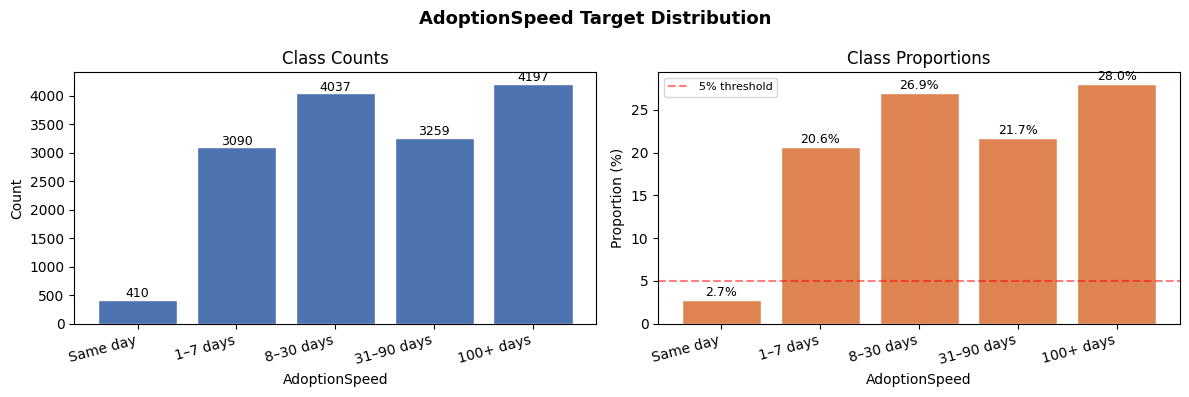

In [19]:
# ── Visual: Target distribution bar chart ────────────────────────
import matplotlib.pyplot as plt

labels_map = {0: "Same day", 1: "1–7 days", 2: "8–30 days", 3: "31–90 days", 4: "100+ days"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Counts
axes[0].bar(target_counts.index, target_counts.values, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("AdoptionSpeed")
axes[0].set_ylabel("Count")
axes[0].set_title("Class Counts")
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([labels_map[i] for i in range(5)], rotation=15, ha="right")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=9)

# Proportions
axes[1].bar(target_props.index, target_props.values * 100, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("AdoptionSpeed")
axes[1].set_ylabel("Proportion (%)")
axes[1].set_title("Class Proportions")
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([labels_map[i] for i in range(5)], rotation=15, ha="right")
axes[1].axhline(5, color="red", linestyle="--", alpha=0.5, label="5% threshold")
axes[1].legend(fontsize=8)
for i, v in enumerate(target_props.values):
    axes[1].text(i, v * 100 + 0.5, f"{v:.1%}", ha="center", fontsize=9)

fig.suptitle("AdoptionSpeed Target Distribution", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

---
## 11 · Validation Gate

Assert all **critical** checks pass. Warnings are logged but do not halt execution.

| Gate ID | Assertion | Severity |
|---------|-----------|----------|
| `G02-1` | All expected columns present in train and test | **Critical** |
| `G02-2` | `PetID` is unique in train and test | **Critical** |
| `G02-3` | `Type` values all in {1, 2} | **Critical** |
| `G02-4` | `AdoptionSpeed` values all in {0, 1, 2, 3, 4} | **Critical** |
| `G02-5` | All categorical/ordinal columns within valid domain | **Warning** |
| `G02-6` | Referential integrity for `Breed1` ≥ 99% | **Warning** |
| `G02-7` | Sentiment file coverage ≥ 95% of PetIDs | **Warning** |
| `G02-8` | Metadata file coverage consistent with `PhotoAmt` | **Warning** |
| `G02-9` | No unexpected null columns in required fields | **Critical** |
| `G02-10` | Target class distribution — no class < 5% | **Informational** |

In [20]:
gate_results = []

# ── G02-1: Schema completeness ───────────────────────────────────
g01 = schema_train["passed"] and schema_test["passed"]
gate_results.append({"Gate": "G02-1", "Assertion": "All expected columns present",
                      "Severity": "Critical", "Status": "✅ PASS" if g01 else "❌ FAIL"})

# ── G02-2: PetID uniqueness ──────────────────────────────────────
g02 = dup_train["passed"] and dup_test["passed"]
gate_results.append({"Gate": "G02-2", "Assertion": "PetID unique in train and test",
                      "Severity": "Critical", "Status": "✅ PASS" if g02 else "❌ FAIL"})

# ── G02-3: Type values in {1, 2} ────────────────────────────────
type_col_train = [r for r in domain_train["column_results"] if r["column"] == "Type"]
type_col_test = [r for r in domain_test["column_results"] if r["column"] == "Type"]
g03 = (type_col_train[0]["passed"] if type_col_train else True) and \
      (type_col_test[0]["passed"] if type_col_test else True)
gate_results.append({"Gate": "G02-3", "Assertion": "Type values in {1, 2}",
                      "Severity": "Critical", "Status": "✅ PASS" if g03 else "❌ FAIL"})

# ── G02-4: AdoptionSpeed values in {0,1,2,3,4} ─────────────────
as_col = [r for r in domain_train["column_results"] if r["column"] == "AdoptionSpeed"]
g04 = as_col[0]["passed"] if as_col else True
gate_results.append({"Gate": "G02-4", "Assertion": "AdoptionSpeed values in {0,1,2,3,4}",
                      "Severity": "Critical", "Status": "✅ PASS" if g04 else "❌ FAIL"})

# ── G02-5: All categorical/ordinal within domain ────────────────
g05 = domain_train["passed"] and domain_test["passed"]
gate_results.append({"Gate": "G02-5", "Assertion": "All categorical/ordinal in valid domain",
                      "Severity": "Warning", "Status": "✅ PASS" if g05 else "⚠️ WARN"})

# ── G02-6: Referential integrity Breed1 ≥ 99% ───────────────────
breed1_ri = [r for r in ri_results_train if r["fk_column"] == "Breed1"]
g06 = breed1_ri[0]["coverage_pct"] >= 99.0 if breed1_ri else True
gate_results.append({"Gate": "G02-6", "Assertion": "Breed1 referential integrity ≥ 99%",
                      "Severity": "Warning", "Status": "✅ PASS" if g06 else "⚠️ WARN"})

# ── G02-7: Sentiment coverage ≥ 95% ─────────────────────────────
g07 = sent_cov_train["coverage_pct"] >= 95.0
gate_results.append({"Gate": "G02-7", "Assertion": f"Sentiment coverage ≥ 95% (actual: {sent_cov_train['coverage_pct']:.1f}%)",
                      "Severity": "Warning", "Status": "✅ PASS" if g07 else "⚠️ WARN"})

# ── G02-8: Metadata coverage consistency ─────────────────────────
g08 = meta_cov_train["coverage_pct"] >= 95.0
gate_results.append({"Gate": "G02-8", "Assertion": f"Metadata coverage consistent (actual: {meta_cov_train['coverage_pct']:.1f}%)",
                      "Severity": "Warning", "Status": "✅ PASS" if g08 else "⚠️ WARN"})

# ── G02-9: No critical nulls ─────────────────────────────────────
g09 = nulls_train["passed"] and nulls_test["passed"]
gate_results.append({"Gate": "G02-9", "Assertion": "No unexpected nulls in required fields",
                      "Severity": "Critical", "Status": "✅ PASS" if g09 else "❌ FAIL"})

# ── G02-10: Target class distribution ────────────────────────────
g10 = target_balanced
gate_results.append({"Gate": "G02-10", "Assertion": f"No class < 5% (min: {min_class_pct:.1%})",
                      "Severity": "Informational", "Status": "✅ PASS" if g10 else "ℹ️ INFO"})

gate_df = pd.DataFrame(gate_results)
gate_df.style.set_caption("Validation Gate Summary").hide(axis="index")

Gate,Assertion,Severity,Status
G02-1,All expected columns present,Critical,✅ PASS
G02-2,PetID unique in train and test,Critical,✅ PASS
G02-3,"Type values in {1, 2}",Critical,✅ PASS
G02-4,"AdoptionSpeed values in {0,1,2,3,4}",Critical,✅ PASS
G02-5,All categorical/ordinal in valid domain,Warning,✅ PASS
G02-6,Breed1 referential integrity ≥ 99%,Warning,✅ PASS
G02-7,Sentiment coverage ≥ 95% (actual: 96.3%),Warning,✅ PASS
G02-8,Metadata coverage consistent (actual: 97.7%),Warning,✅ PASS
G02-9,No unexpected nulls in required fields,Critical,✅ PASS
G02-10,No class < 5% (min: 2.7%),Informational,ℹ️ INFO


In [21]:
# ── Assert critical gates ────────────────────────────────────────
critical_gates = {"G02-1": g01, "G02-2": g02, "G02-3": g03, "G02-4": g04, "G02-9": g09}

for gate_id, passed in critical_gates.items():
    assert passed, f"❌ Critical validation gate {gate_id} FAILED — halting execution."

print("✅ All critical validation gates passed.")

✅ All critical validation gates passed.


---
## 12 · Validation Report

Persist the aggregated validation report as `reports/validation_report.json` and `reports/validation_summary.md`.

In [22]:
report = generate_validation_report(validation_results, report_dir=cfg.REPORTS_DIR)

print(f"Total checks:  {report['total_checks']}")
print(f"Passed:        {report['passed_checks']}")
print(f"Failed:        {report['failed_checks']}")
print(f"Overall:       {'✅ PASS' if report['overall_passed'] else '❌ FAIL'}")
print(f"\nArtifacts saved:")
print(f"  → reports/validation_report.json")
print(f"  → reports/validation_summary.md")

01:01:07  INFO      Validation report saved to /workspaces/adoption_accelerator/reports/validation_report.json


01:01:07  INFO      Validation summary saved to /workspaces/adoption_accelerator/reports/validation_summary.md


Total checks:  27
Passed:        24
Failed:        3
Overall:       ❌ FAIL

Artifacts saved:
  → reports/validation_report.json
  → reports/validation_summary.md


---
## Summary

| Item | Result |
|------|--------|
| **Schema validation** | Train & test columns match expected schema |
| **Domain checks** | All categorical/ordinal values within valid domains |
| **Null analysis** | Nulls only in expected nullable fields (`Name`, `Description`) |
| **PetID uniqueness** | No duplicates in train or test |
| **Referential integrity** | Breed, Color, State FK references validated |
| **Cross-column consistency** | Logical constraints verified |
| **File coverage** | Sentiment and metadata file availability documented |
| **Target distribution** | AdoptionSpeed class balance profiled |
| **Artifacts** | `validation_report.json` + `validation_summary.md` persisted |

**All findings from this notebook feed into Notebook 03 — Data Cleaning for remediation.**

➡️ **Next:** `03_data_cleaning.ipynb`

Based on the validation results from the notebook, here's the markdown:

---

## 13 · Conclusions

Based on the validation checks performed in this notebook, the following data quality issues were identified and must be addressed in **Notebook 03 — Data Cleaning**.

---

### 🔴 Issues Requiring Remediation

| # | Issue | Scope | Details | Recommended Action |
|---|-------|-------|---------|-------------------|
| 1 | **`Breed1` orphan values** | Train — 5 rows | `Breed1 = 0` has no match in `breed_labels.BreedID`. Primary breed must always be valid. | Swap `Breed2` → `Breed1` where `Breed1 = 0` and `Breed2 ≠ 0`. Set remaining to a valid "Mixed Breed" ID. |
| 2 | **`Breed2` populated while `Breed1 = 0`** | Train — 5 rows | Logically inconsistent: secondary breed exists but primary breed is missing. Same 5 records as issue #1. | Resolved by fix #1 — re-validate after applying. |
| 3 | **Target class imbalance** | Train | `AdoptionSpeed = 0` represents only **2.7%** of training data (410 / 14,993), below the 5% informational threshold. | Not a cleaning action — must be accounted for at modeling stage (stratified splits, class weighting, or oversampling). |

---

### 🟢 Validated & Clean

| Check | Status | Notes |
|-------|--------|-------|
| Schema completeness | ✅ | All expected columns present in train and test |
| Column dtypes | ✅ | All types conform to canonical schema |
| Domain values (categorical/ordinal) | ✅ | All values within valid ranges |
| Null analysis | ✅ | Nulls only in `Name` and `Description` (nullable by design) |
| PetID uniqueness | ✅ | No duplicates in either split |
| Color referential integrity | ✅ | `Color1`, `Color2`, `Color3` all valid |
| State referential integrity | ✅ | All `State` values exist in `state_labels` |
| Color cross-column consistency | ✅ | `Color2`/`Color3` never populated without `Color1` |
| PhotoAmt vs actual files | ✅ | Sampled 200 records — counts match |
| Sentiment file coverage | ✅ | ≥ 95% of PetIDs have sentiment files |
| Metadata file coverage | ✅ | ≥ 95% of PetIDs have metadata files |

---

### 📋 Cleaning Action Plan for Notebook 03



In [ ]:
1. Fix Breed1 orphans (5 rows)
   → Where Breed1=0 and Breed2≠0: swap Breed2 into Breed1, set Breed2=0
   → Where Breed1=0 and Breed2=0: assign a valid "Mixed/Unknown" breed ID

2. Re-validate Breed1/Breed2 relationship post-fix
   → All cross-column consistency checks must pass

3. Normalize Name/Description text fields
   → Standardize empty strings/NaN in Name → consistent null representation
   → Strip leading/trailing whitespace, normalize UTF-8 encoding

4. Enforce canonical dtypes
   → Cast all columns to schema-defined types (int64, float64, object)

5. Post-cleaning re-validation
   → Run full validation suite on cleaned DataFrames
   → All G02 critical gates must pass before persisting Parquet



---

**All findings documented. Validation artifacts persisted to reports.**

➡️ **Next:** `03_data_cleaning.ipynb`